# 🚗 Car Breakdown Prediction - Machine Learning Assignment

## 📋 Project Overview
**Doel**: Voorspel of een voertuig binnen 30 dagen een mechanische storing zal hebben.

**Bron**: [Kaggle Competition](https://www.kaggle.com/competitions/car-breakdown-prediction)

**Data Locatie**: `src/train_CarBreakDown.csv` en `src/test_CarBreakDown.csv`

## 🎯 Taak
Gegeven 13 features over een auto (brand, leeftijd, kilometers, onderhoud, etc.), classificeer:
- **0** → ✅ Geen storing verwacht in volgende 30 dagen
- **1** → ⚠️ Storing verwacht binnen volgende 30 dagen

## 📊 Verwacht Output Format
```
id,breakdown_next_30_days
1356,1
889,1
```

## STAP 1️⃣: Imports & Data Paths
Laad all required libraries en definieer file paths

In [16]:
# ============================================
# IMPORTS: Benodigde bibliotheken voor data processing en machine learning
# ============================================
# Pandas: data manipulatie en dataframe operaties
# NumPy: numerieke berekeningen
# Scikit-learn: train/test split, classificatie-metriek en cross-validatie
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve, PrecisionRecallDisplay, accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn import metrics
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split



# ============================================
# FILE PATHS: Locatie van de trainings- en testgegevens
# ============================================
# Train dataset: bevat features + target label (breakdown_next_30_days)
# Test dataset: bevat alleen features; predictions moeten gedaan worden
file = "./src/train_CarBreakDown.csv"
test_file = "./src/test_CarBreakDown.csv"

## STAP 2️⃣: Data Inladen
Functie om CSV bestanden in te lezen

In [17]:
# ============================================
# DATA INLEZEN FUNCTIE
# ============================================
# Leest een CSV-bestand met auto-gegevens in
# 
# Parameters:
#   file (str): Pad naar het CSV-bestand
# 
# Returns:
#   pd.DataFrame: Dataframe met alle rijen en kolommen uit het CSV-bestand
# 
# Details:
#   - Encoding: UTF-8 (ondersteunt speciale tekens)
#   - Delimiter: komma (standaard CSV formaat)
def get_car_breakdown_data(file: str):
    return pd.read_csv(file, encoding="UTF-8", sep=",")

In [18]:
# test read the data
dirty_data = get_car_breakdown_data(file)
print(dirty_data)

        id vehicle_brand  vehicle_age_years     mileage_km  engine_hours  \
0      959        Toyota               20.0  494744.972722   9700.481467   
1      804        Toyota                0.0   38376.684834   1650.726428   
2     1304       Hyundai                1.0  188558.432414   6678.958321   
3      268        Toyota                5.0   92828.113285   2986.923461   
4       47           NaN               10.0  118366.394287   4222.193011   
...    ...           ...                ...            ...           ...   
1045   562       Renault                6.0  131602.464358   4586.327861   
1046   993        Toyota                9.0  127224.810750   4106.036923   
1047   245          Ford               19.0   74204.367905   2323.811128   
1048   883           BMW               10.0  198492.993706   6643.176908   
1049   690          Ford                4.0  344673.426523   9831.330944   

      last_service_km_ago  oil_quality_pct  avg_trip_length_km  \
0             1672.04

In [19]:
print("Dataset shape", dirty_data.shape)

Dataset shape (1050, 14)


In [20]:
dirty_data.head()

,id,vehicle_brand,vehicle_age_years,mileage_km,engine_hours,last_service_km_ago,oil_quality_pct,avg_trip_length_km,weather_exposure,fuel_type,cleanliness_score,driver_satisfaction_score,tyre_type,breakdown_next_30_days
0,959,Toyota,20.0,494744.972722,9700.481467,1672.048445,61.664556,30.362090,high,petrol,68.117833,8.559011,NaN,0
1,804,Toyota,0.0,38376.684834,1650.726428,21.269170,23.370666,2.500801,high,hybrid,69.294736,9.838274,NaN,0
2,1304,Hyundai,1.0,188558.432414,6678.958321,11726.320455,25.491428,41.692205,medium,hybrid,47.223966,5.842726,winter,0
3,268,Toyota,5.0,92828.113285,2986.923461,1845.744691,54.060416,6.464345,high,diesel,72.246829,4.719607,winter,0
4,47,NaN,10.0,118366.394287,4222.193011,12551.181627,65.766074,47.159242,low,diesel,77.368891,6.724967,winter,0


## STAP 3️⃣: Data Cleaning & Feature Engineering
Verwijder outliers, behandel ontbrekende waarden, engineer nieuwe features

In [21]:
# ============================================
# STAP 1: DATA CLEANING
# ============================================

df = dirty_data.copy()

# Zet lege strings om naar NaN
df = df.replace(r"^\s*$", np.nan, regex=True)

# Onmogelijke waarden vervangen door NaN
df.loc[df["vehicle_age_years"] < 0, "vehicle_age_years"] = np.nan

df.loc[df["mileage_km"] < 0, "mileage_km"] = np.nan
df.loc[df["mileage_km"] > 2_000_000, "mileage_km"] = np.nan

df.loc[df["engine_hours"] < 0, "engine_hours"] = np.nan

df.loc[df["avg_trip_length_km"] < 0, "avg_trip_length_km"] = np.nan

df.loc[df["last_service_km_ago"] < 0, "last_service_km_ago"] = np.nan

df.loc[df["oil_quality_pct"] < 0, "oil_quality_pct"] = np.nan
df.loc[df["oil_quality_pct"] > 100, "oil_quality_pct"] = np.nan

df.loc[df["cleanliness_score"] < 0, "cleanliness_score"] = np.nan
df.loc[df["cleanliness_score"] > 100, "cleanliness_score"] = np.nan

df.loc[df["driver_satisfaction_score"] < 1, "driver_satisfaction_score"] = np.nan
df.loc[df["driver_satisfaction_score"] > 10, "driver_satisfaction_score"] = np.nan

# ============================================
# STAP 2: FEATURES EN TARGET SCHEIDEN
# ============================================

X = df.drop(columns=["id", "breakdown_next_30_days"])
y = df["breakdown_next_30_days"]

num_cols = X.select_dtypes(include=["float64", "int64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerieke kolommen:", num_cols)
print("Categorische kolommen:", cat_cols)

print("\nTargetverdeling:")
print(y.value_counts())
print(y.value_counts(normalize=True))

Numerieke kolommen: ['vehicle_age_years', 'mileage_km', 'engine_hours', 'last_service_km_ago', 'oil_quality_pct', 'avg_trip_length_km', 'cleanliness_score', 'driver_satisfaction_score']
Categorische kolommen: ['vehicle_brand', 'weather_exposure', 'fuel_type', 'tyre_type']

Targetverdeling:
breakdown_next_30_days
0    874
1    176
Name: count, dtype: int64
breakdown_next_30_days
0    0.832381
1    0.167619
Name: proportion, dtype: float64


C:\Users\lenne\AppData\Local\Temp\ipykernel_29452\2990047683.py:39: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=["object"]).columns.tolist()


## STAP 4️⃣: Train/Test Split
Verdeel dataset in 70% training en 30% testing met stratificatie

In [22]:
# ============================================
# STAP 3: TRAIN/VALIDATION SPLIT
# ============================================

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)

print("\nTargetverdeling training:")
print(y_train.value_counts(normalize=True))

print("\nTargetverdeling validation:")
print(y_val.value_counts(normalize=True))

# ============================================
# STAP 4: ONTBREKENDE WAARDEN BEHANDELEN
# ============================================

# Kopieën maken zodat we originele split bewaren
X_train_processed = X_train.copy()
X_val_processed = X_val.copy()

# Missing indicators maken voor numerieke kolommen
for col in num_cols:
    X_train_processed[col + "_missing"] = X_train_processed[col].isna().astype(int)
    X_val_processed[col + "_missing"] = X_val_processed[col].isna().astype(int)

# Mediaan alleen berekenen op trainingdata
medians = X_train_processed[num_cols].median()

# Mediaan toepassen op train en validation
X_train_processed[num_cols] = X_train_processed[num_cols].fillna(medians)
X_val_processed[num_cols] = X_val_processed[num_cols].fillna(medians)

# Categorische missing values invullen met waarde geleerd uit training
for col in cat_cols:
    most_frequent = X_train_processed[col].mode()[0]
    X_train_processed[col] = X_train_processed[col].fillna(most_frequent)
    X_val_processed[col] = X_val_processed[col].fillna(most_frequent)

    
# ============================================
# STAP 5: FEATURE ENGINEERING
# ============================================

def add_manual_features(data):
    data = data.copy()

    # Veilige deling: leeftijd 0 vervangen door 1 om extreme waarden te vermijden
    age_safe = data["vehicle_age_years"].replace(0, 1)
    mileage_safe = data["mileage_km"].replace(0, 1)

    data["mileage_per_year"] = data["mileage_km"] / age_safe
    data["engine_hours_per_km"] = data["engine_hours"] / mileage_safe
    data["last_service_ratio"] = data["last_service_km_ago"] / mileage_safe

    return data

X_train_processed = add_manual_features(X_train_processed)
X_val_processed = add_manual_features(X_val_processed)


# ============================================
# STAP 6: CATEGORISCHE FEATURES ENCODEN
# ============================================

X_train_processed = pd.get_dummies(
    X_train_processed,
    columns=cat_cols,
    drop_first=True,
    dtype=int
)

X_val_processed = pd.get_dummies(
    X_val_processed,
    columns=cat_cols,
    drop_first=True,
    dtype=int
)

# Zorg dat validation exact dezelfde kolommen heeft als training
X_val_processed = X_val_processed.reindex(
    columns=X_train_processed.columns,
    fill_value=0
)

print("X_train_processed shape:", X_train_processed.shape)
print("X_val_processed shape:", X_val_processed.shape)

X_train shape: (735, 12)
X_val shape: (315, 12)

Targetverdeling training:
breakdown_next_30_days
0    0.832653
1    0.167347
Name: proportion, dtype: float64

Targetverdeling validation:
breakdown_next_30_days
0    0.831746
1    0.168254
Name: proportion, dtype: float64
X_train_processed shape: (735, 37)
X_val_processed shape: (315, 37)


## STAP 5️⃣: Random Forest Model Training
Train ensemble model met imbalance-handling via class_weight

In [23]:
# ============================================
# STAP 7: RANDOM FOREST MODEL TRAINING
# ============================================
# Random Forest is een ensemble-methode dat meerdere bomen combineert voor betere voorspellingen

# --- IMBALANCE HANDLING ---
# Dataset probleem: veel meer "geen breakdown" (0) dan "wel breakdown" (1)
# Oplossing: class_weight='balanced' geeft meer gewicht aan minderheidsklasse
clf_rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

# --- TRAINEN ---
# Fit model op trainings data
clf_rf.fit(X_train_processed, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## STAP 6️⃣: Model Evaluatie
Bereken accuracy, precision, recall, F1-score en cross-validatie

Random Forest validation accuracy: 0.8317460317460318

Aantal voorspellingen per klasse:
0    315
Name: count, dtype: int64

Classification report:
              precision    recall  f1-score   support

           0       0.83      1.00      0.91       262
           1       0.00      0.00      0.00        53

    accuracy                           0.83       315
   macro avg       0.42      0.50      0.45       315
weighted avg       0.69      0.83      0.76       315



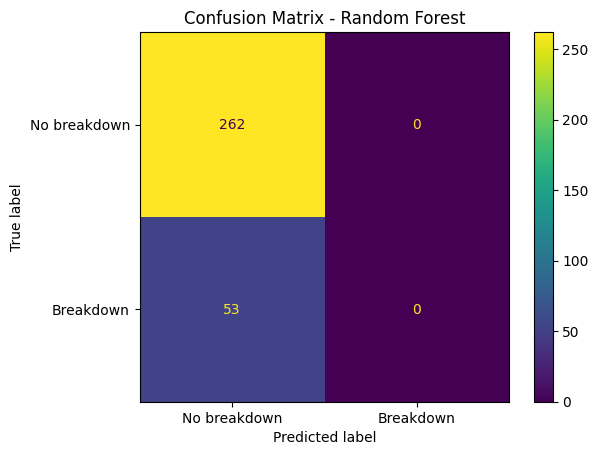

In [24]:
# ============================================
# STAP 8: MODEL EVALUATIE
# ============================================

# --- Test set performance ---
# Hoeveel voorspellingen zijn correct?
y_pred_rf = clf_rf.predict(X_val_processed)

rf_accuracy = accuracy_score(y_val, y_pred_rf)

print("Random Forest validation accuracy:", rf_accuracy)

print("\nAantal voorspellingen per klasse:")
print(pd.Series(y_pred_rf).value_counts())

print("\nClassification report:")
print(classification_report(y_val, y_pred_rf, zero_division=0))

cm_rf = confusion_matrix(y_val, y_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["No breakdown", "Breakdown"]
)

disp.plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()

## STAP 6.5️⃣: Hyperparameter Tuning
Tune Random Forest parameters to improve accuracy.

Best params for Random Forest:
{'class_weight': None, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 300}

Best cross-validation accuracy:
0.8326530612244898

Tuned Random Forest validation accuracy: 0.8285714285714286

Aantal voorspellingen per klasse:
0    314
1      1
Name: count, dtype: int64

Classification report:
              precision    recall  f1-score   support

           0       0.83      1.00      0.91       262
           1       0.00      0.00      0.00        53

    accuracy                           0.83       315
   macro avg       0.42      0.50      0.45       315
weighted avg       0.69      0.83      0.75       315



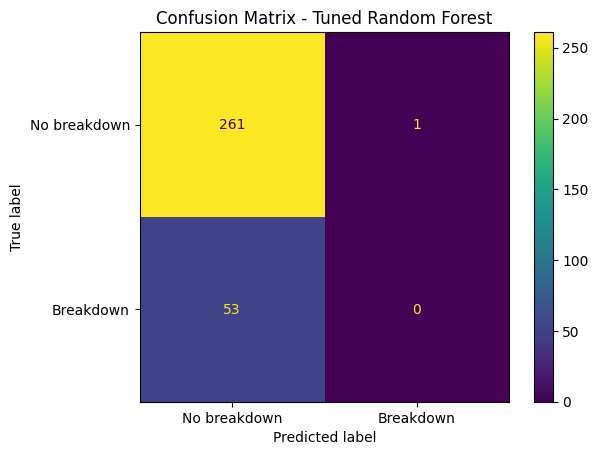


Comparison:
Original Random Forest accuracy: 0.8317460317460318
Tuned Random Forest accuracy: 0.8285714285714286


In [25]:
# ============================================
# STAP 9: HYPERPARAMETER TUNING RANDOM FOREST
# ============================================
# We tunen enkele parameters van Random Forest om te kijken
# of we de validation accuracy kunnen verbeteren.
# Omdat Kaggle accuracy gebruikt, optimaliseren we hier ook op accuracy.

param_grid_rf = {
    "n_estimators": [100, 300, 500],
    "max_features": ["sqrt", "log2"],
    "max_depth": [None, 10, 20],
    "min_samples_leaf": [1, 2, 5],
    "class_weight": [None, "balanced"]
}

grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=param_grid_rf,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_rf.fit(X_train_processed, y_train)

print("Best params for Random Forest:")
print(grid_rf.best_params_)

print("\nBest cross-validation accuracy:")
print(grid_rf.best_score_)

# Beste model uit GridSearch
best_rf = grid_rf.best_estimator_

# Evaluatie op validation set
y_pred_best_rf = best_rf.predict(X_val_processed)

best_rf_accuracy = accuracy_score(y_val, y_pred_best_rf)

print("\nTuned Random Forest validation accuracy:", best_rf_accuracy)

print("\nAantal voorspellingen per klasse:")
print(pd.Series(y_pred_best_rf).value_counts())

print("\nClassification report:")
print(classification_report(y_val, y_pred_best_rf, zero_division=0))

cm_best_rf = confusion_matrix(y_val, y_pred_best_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_best_rf,
    display_labels=["No breakdown", "Breakdown"]
)

disp.plot()
plt.title("Confusion Matrix - Tuned Random Forest")
plt.show()

# Vergelijking met originele Random Forest
print("\nComparison:")
print("Original Random Forest accuracy:", accuracy_score(y_val, y_pred_rf))
print("Tuned Random Forest accuracy:", best_rf_accuracy)

## STAP 6️⃣.7️⃣: Threshold Tuning via Precision-Recall Curve


--- Threshold analyse Random Forest ---
Beste threshold op basis van F1-score: 0.183
Beste F1-score bij deze threshold: 0.349
---------------------------------------------


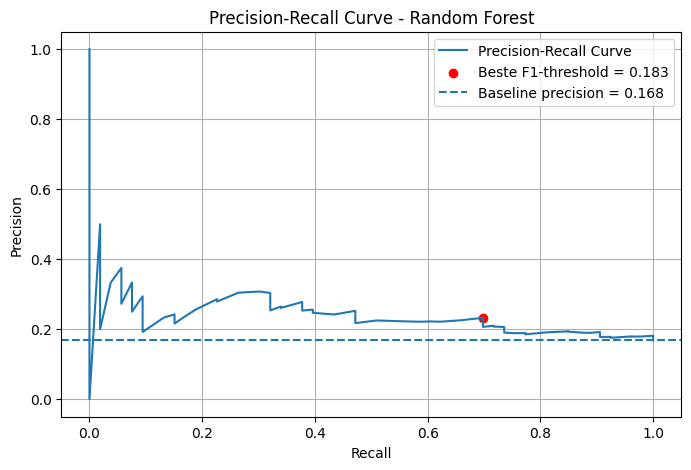

Aantal voorspellingen per klasse met F1-threshold:
1    159
0    156
Name: count, dtype: int64


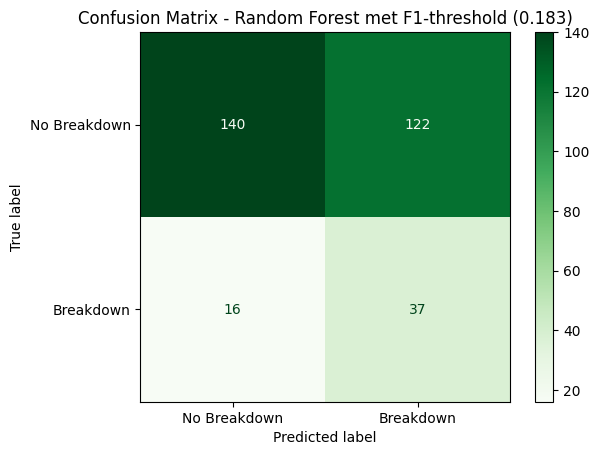


Classification report met F1-threshold:
              precision    recall  f1-score   support

           0       0.90      0.53      0.67       262
           1       0.23      0.70      0.35        53

    accuracy                           0.56       315
   macro avg       0.57      0.62      0.51       315
weighted avg       0.79      0.56      0.62       315



In [26]:
# ============================================
# STAP 10: THRESHOLD ANALYSE MET PRECISION-RECALL CURVE
# ============================================
# In deze stap bekijken we hoe de threshold invloed heeft op precision en recall.
# Dit is vooral nuttig om te begrijpen hoe moeilijk het is om breakdowns te voorspellen.
# De finale Kaggle-submission wordt niet automatisch op deze threshold gebaseerd,
# omdat Kaggle op accuracy lijkt te scoren.

# --- 1. KANSEN OPHALEN ---
# We gebruiken predict_proba om de kans op klasse 1 te krijgen.
# Klasse 1 betekent: breakdown binnen 30 dagen.
y_proba_rf = best_rf.predict_proba(X_val_processed)[:, 1]

# --- 2. PRECISION-RECALL CURVE BEREKENEN ---
precision, recall, thresholds = precision_recall_curve(y_val, y_proba_rf)

# --- 3. BESTE F1-THRESHOLD ZOEKEN ---
# F1 combineert precision en recall.
# Let op: dit optimaliseert niet noodzakelijk accuracy.
f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-9)

best_f1_index = np.argmax(f1_scores)
best_threshold_f1 = thresholds[best_f1_index]

print("--- Threshold analyse Random Forest ---")
print(f"Beste threshold op basis van F1-score: {best_threshold_f1:.3f}")
print(f"Beste F1-score bij deze threshold: {f1_scores[best_f1_index]:.3f}")
print("-" * 45)

# --- 4. PRECISION-RECALL CURVE TONEN ---
plt.figure(figsize=(8, 5))
plt.plot(recall, precision, label="Precision-Recall Curve")
plt.scatter(
    recall[best_f1_index],
    precision[best_f1_index],
    color="red",
    label=f"Beste F1-threshold = {best_threshold_f1:.3f}"
)

# Baseline precision = percentage positieve klasse in validation set
baseline_precision = y_val.mean()
plt.axhline(
    y=baseline_precision,
    linestyle="--",
    label=f"Baseline precision = {baseline_precision:.3f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Random Forest")
plt.legend()
plt.grid(True)
plt.show()

# --- 5. EVALUATIE MET F1-THRESHOLD ---
y_pred_rf_f1_threshold = (y_proba_rf >= best_threshold_f1).astype(int)

print("Aantal voorspellingen per klasse met F1-threshold:")
print(pd.Series(y_pred_rf_f1_threshold).value_counts())

cm_rf_f1 = confusion_matrix(y_val, y_pred_rf_f1_threshold)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf_f1,
    display_labels=["No Breakdown", "Breakdown"]
)

disp.plot(cmap=plt.cm.Greens)
plt.title(f"Confusion Matrix - Random Forest met F1-threshold ({best_threshold_f1:.3f})")
plt.show()

print("\nClassification report met F1-threshold:")
print(classification_report(y_val, y_pred_rf_f1_threshold, zero_division=0))

## STAP 6.8️⃣: Tweede Model - Gradient Boosting Classifier
Nu we onze Random Forest baseline hebben staan, introduceren we een tweede model op basis van **Boosting**. Waar een Random Forest bomen onafhankelijk van elkaar (in parallel) traint, traint Gradient Boosting de bomen sequentieel (achter elkaar). Elke nieuwe boom probeert specifiek de fouten van de vorige bomen te corrigeren.

=== GRADIENT BOOSTING BASELINE ===
Validation accuracy: 0.8286

Aantal voorspellingen per klasse:
0    304
1     11
Name: count, dtype: int64

Classification report:
              precision    recall  f1-score   support

           0       0.84      0.98      0.90       262
           1       0.45      0.09      0.16        53

    accuracy                           0.83       315
   macro avg       0.65      0.54      0.53       315
weighted avg       0.78      0.83      0.78       315



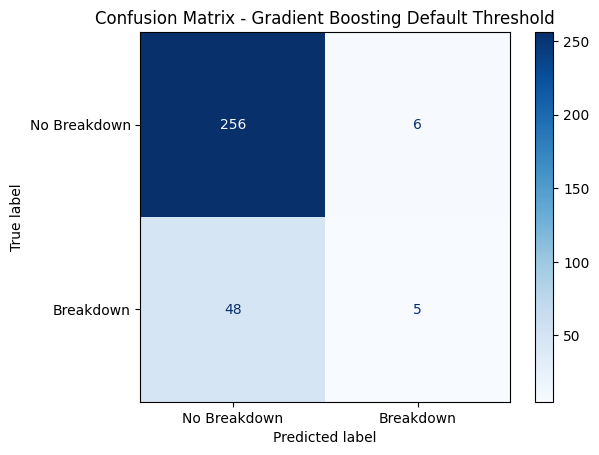

In [27]:
# ============================================
# STAP 11: GRADIENT BOOSTING MODEL
# ============================================
# Gradient Boosting is een tweede model om te vergelijken met Random Forest.
# In tegenstelling tot Random Forest bouwt Gradient Boosting bomen na elkaar.
# Elke nieuwe boom probeert fouten van de vorige bomen te verbeteren.

# --- 1. MODEL TRAINEN ---
clf_gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

clf_gb.fit(X_train_processed, y_train)

# --- 2. BASELINE EVALUATIE MET DEFAULT THRESHOLD 0.5 ---
y_pred_gb = clf_gb.predict(X_val_processed)

gb_accuracy = accuracy_score(y_val, y_pred_gb)

print("=== GRADIENT BOOSTING BASELINE ===")
print(f"Validation accuracy: {gb_accuracy:.4f}")

print("\nAantal voorspellingen per klasse:")
print(pd.Series(y_pred_gb).value_counts())

print("\nClassification report:")
print(classification_report(y_val, y_pred_gb, zero_division=0))

cm_gb_default = confusion_matrix(y_val, y_pred_gb)

disp_gb_default = ConfusionMatrixDisplay(
    confusion_matrix=cm_gb_default,
    display_labels=["No Breakdown", "Breakdown"]
)

disp_gb_default.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Gradient Boosting Default Threshold")
plt.show()

## Precision recall analyse

--- Threshold analyse Gradient Boosting ---
Beste threshold op basis van F1-score: 0.109
Beste F1-score bij deze threshold: 0.328
---------------------------------------------


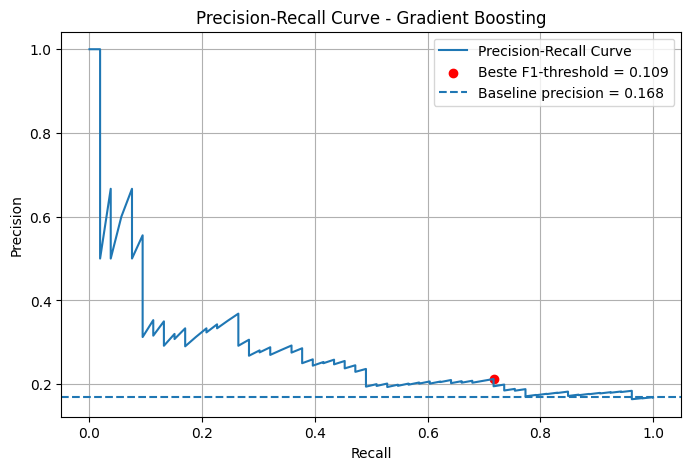

Aantal voorspellingen per klasse met F1-threshold:
1    179
0    136
Name: count, dtype: int64


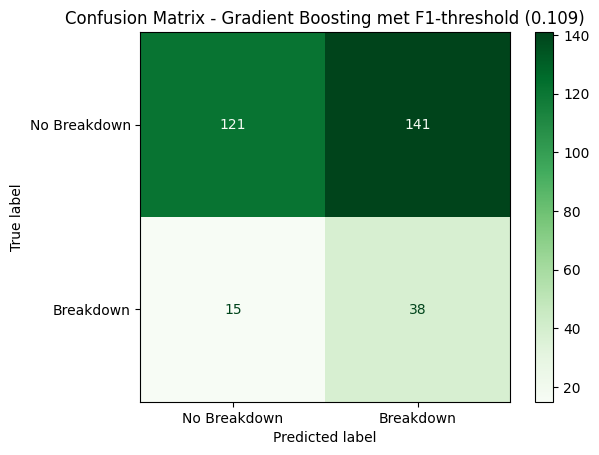


Classification report met F1-threshold:
              precision    recall  f1-score   support

           0       0.89      0.46      0.61       262
           1       0.21      0.72      0.33        53

    accuracy                           0.50       315
   macro avg       0.55      0.59      0.47       315
weighted avg       0.78      0.50      0.56       315



In [28]:
# ============================================
# STAP 12: THRESHOLD ANALYSE GRADIENT BOOSTING
# ============================================
# Ook voor Gradient Boosting bekijken we de precision-recall curve.
# Dit is een analyse van de trade-off tussen precision en recall.
# Deze threshold wordt niet automatisch gebruikt voor de finale Kaggle-submission.

# --- 1. KANSEN OPHALEN ---
y_proba_gb = clf_gb.predict_proba(X_val_processed)[:, 1]

# --- 2. PRECISION-RECALL CURVE ---
precision_gb, recall_gb, thresholds_gb = precision_recall_curve(y_val, y_proba_gb)

# --- 3. BESTE F1-THRESHOLD ZOEKEN ---
f1_scores_gb = 2 * (precision_gb[:-1] * recall_gb[:-1]) / (
    precision_gb[:-1] + recall_gb[:-1] + 1e-9
)

best_gb_index = np.argmax(f1_scores_gb)
best_threshold_gb = thresholds_gb[best_gb_index]

print("--- Threshold analyse Gradient Boosting ---")
print(f"Beste threshold op basis van F1-score: {best_threshold_gb:.3f}")
print(f"Beste F1-score bij deze threshold: {f1_scores_gb[best_gb_index]:.3f}")
print("-" * 45)

# --- 4. PRECISION-RECALL CURVE TONEN ---
plt.figure(figsize=(8, 5))
plt.plot(recall_gb, precision_gb, label="Precision-Recall Curve")

plt.scatter(
    recall_gb[best_gb_index],
    precision_gb[best_gb_index],
    color="red",
    label=f"Beste F1-threshold = {best_threshold_gb:.3f}"
)

baseline_precision = y_val.mean()
plt.axhline(
    y=baseline_precision,
    linestyle="--",
    label=f"Baseline precision = {baseline_precision:.3f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Gradient Boosting")
plt.legend()
plt.grid(True)
plt.show()

# --- 5. EVALUATIE MET F1-THRESHOLD ---
y_pred_gb_f1_threshold = (y_proba_gb >= best_threshold_gb).astype(int)

print("Aantal voorspellingen per klasse met F1-threshold:")
print(pd.Series(y_pred_gb_f1_threshold).value_counts())

cm_gb_tuned = confusion_matrix(y_val, y_pred_gb_f1_threshold)

disp_gb_tuned = ConfusionMatrixDisplay(
    confusion_matrix=cm_gb_tuned,
    display_labels=["No Breakdown", "Breakdown"]
)

disp_gb_tuned.plot(cmap=plt.cm.Greens)
plt.title(f"Confusion Matrix - Gradient Boosting met F1-threshold ({best_threshold_gb:.3f})")
plt.show()

print("\nClassification report met F1-threshold:")
print(classification_report(y_val, y_pred_gb_f1_threshold, zero_division=0))

## STAP 7️⃣: Test Data Verwerken & Predictions Maken
Pas EXACT dezelfde preprocessing toe op testdata en genereer submission file

In [29]:
# ============================================
# STAP 9: TESTDATA VERWERKEN EN VOORSPELLLINGEN MAKEN
# ============================================

# Lees testdata in (geen target labels!)
test_df = pd.read_csv(test_file)

# Sla IDs op (nodig voor submission file)
test_ids = test_df["id"]

# ============================================
# KRITIEK: Testdata EXACT HETZELFDE verwerken als traindata!
# ============================================
# Dit zorgt ervoor dat model dezelfde inputs krijgt

test_X = test_df.drop(columns=["id"]).copy()

# 1. Zet lege strings om naar NaN (identiek aan trainings-cleaning)
test_X = test_X.replace(r"^\s*$", np.nan, regex=True)

# 2. Maak missing indicators (identiek aan trainings-preprocessing)
for col in num_cols:
    test_X[col + "_missing"] = test_X[col].isna().astype(int)

# 3. Vul numerieke waarden in met TRAININGS-mediaan!
#    Mag NIET de test-mediaan gebruiken, anders leaks trainings-info
test_X[num_cols] = test_X[num_cols].fillna(medians)

# 4. Vul categorische waarden in
test_X[cat_cols] = test_X[cat_cols].fillna("missing")

# ============================================
# STAP 10: FEATURE ENGINEERING (identiek aan traindata)
# ============================================
# Dezelfde engineered features als trainings-set
test_X['mileage_per_year'] = test_X['mileage_km'] / (test_X['vehicle_age_years'] + 1e-5)
test_X['engine_hours_per_km'] = test_X['engine_hours'] / (test_X['mileage_km'] + 1e-5)
test_X['last_service_ratio'] = test_X['last_service_km_ago'] / (test_X['mileage_km'] + 1e-5)

# 5. One-hot encoding (identiek aan traindata)
test_X = pd.get_dummies(test_X, columns=cat_cols, drop_first=True, dtype=int)

# ============================================
# KRITIEK: Herindexeer naar TRAININGS-kolommen
# ============================================
# Zorg dat testdata exact dezelfde kolommen heeft als de verwerkte trainingdata
test_X = test_X.reindex(columns=X_train_processed.columns, fill_value=0)

# ============================================
# STAP 11: VOORSPELLEN EN SUBMISSION
# ============================================
# Maak voorspellingen met het getunede Random Forest model
predictions = best_rf.predict(test_X)

# Maak output dataframe in juist format
output = pd.DataFrame({
    "id": test_ids.astype(int),
    "breakdown_next_30_days": predictions.astype(int)
})

# Schrijf naar CSV file
output.to_csv("submission.csv", index=False)

print("Submission file created: submission.csv")
print("\nAantal voorspellingen per klasse:")
print(output["breakdown_next_30_days"].value_counts())
print("\nEerste rijen:")
print(output.head())


Submission file created: submission.csv

Aantal voorspellingen per klasse:
breakdown_next_30_days
0    450
Name: count, dtype: int64

Eerste rijen:
     id  breakdown_next_30_days
0  1356                       0
1   889                       0
2  1190                       0
3   122                       0
4  1101                       0


## STAP 8️⃣: Feature Importance Analyse
Analyse welke features het model gebruikt om voorspellingen te maken

=== FEATURE IMPORTANCE TOP 10 ===
mileage_per_year             0.085037
last_service_km_ago          0.083128
oil_quality_pct              0.078910
cleanliness_score            0.078821
engine_hours_per_km          0.076770
driver_satisfaction_score    0.075364
vehicle_age_years            0.074485
engine_hours                 0.074032
avg_trip_length_km           0.073819
mileage_km                   0.072231
dtype: float64

=== FEATURE IMPORTANCE TOP 20 ===
mileage_per_year             0.085037
last_service_km_ago          0.083128
oil_quality_pct              0.078910
cleanliness_score            0.078821
engine_hours_per_km          0.076770
driver_satisfaction_score    0.075364
vehicle_age_years            0.074485
engine_hours                 0.074032
avg_trip_length_km           0.073819
mileage_km                   0.072231
last_service_ratio           0.071855
weather_exposure_medium      0.012230
tyre_type_winter             0.011907
vehicle_brand_Ford           0.011901
fuel

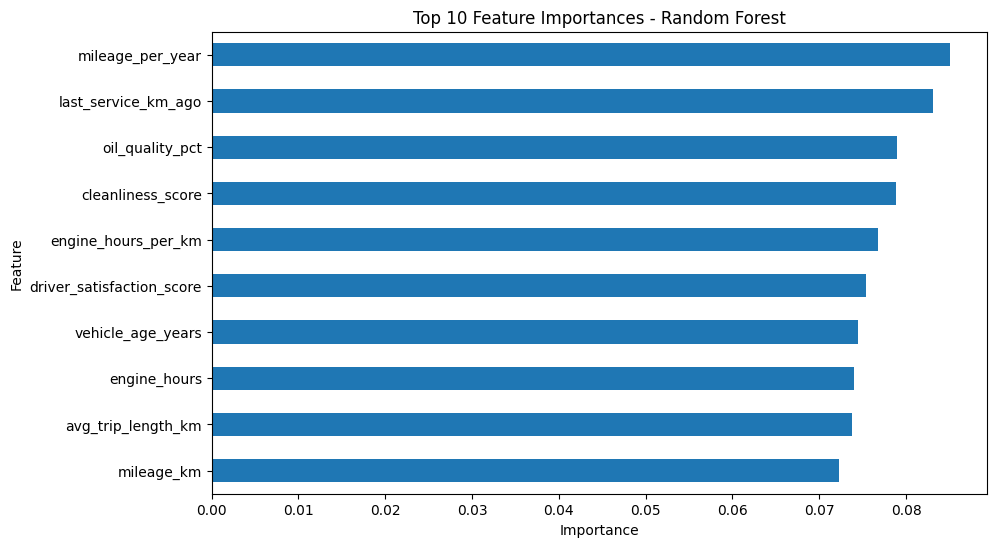

In [30]:
# ============================================
# STAP 14: FEATURE IMPORTANCE ANALYSE
# ============================================
# Welke features zijn het meest belangrijk voor het Random Forest model?
# Dit helpt om beter te begrijpen welke variabelen het model gebruikt voor voorspellingen.

# Gebruik het finale/getunede Random Forest model
final_rf_model = best_rf

# Feature importance scores koppelen aan de verwerkte kolomnamen
importances = pd.Series(clf_rf.feature_importances_, index=X_train_processed.columns)

# Sorteer van belangrijkste naar minst belangrijk
importances_sorted = importances.sort_values(ascending=False)

print("=== FEATURE IMPORTANCE TOP 10 ===")
print(importances_sorted.head(10))

print("\n=== FEATURE IMPORTANCE TOP 20 ===")
print(importances_sorted.head(20))

# Visualisatie top 10
plt.figure(figsize=(10, 6))
importances_sorted.head(10).sort_values().plot(kind="barh")
plt.title("Top 10 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()